### Libraries

In [1]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import glob
import re
import igraph as ig
import semopy
import seaborn as sns
import string
import warnings

import logging
warnings.filterwarnings("ignore")

### Plot Cumulative Density function

In [38]:
def plot_ECDF(df_col, ax, color='black', linestyle='-', linewidth=2):
    """
    df_col: Série (coluna) contendo p-valores.
    ax: Eixo (subplot) do matplotlib onde o gráfico será desenhado. 
    """
    proportion_rejected_null = []
    # Reduzido de 1000 para 100 para otimizar, mas pode voltar para 1000 se preferir mais suavidade
    x = np.linspace(0, 1, 100) 
    
    for threshold in x:
        proportion = np.mean(df_col < threshold)
        proportion_rejected_null.append(proportion)

    ax.plot(x, proportion_rejected_null, color=color, linestyle=linestyle, linewidth=linewidth, alpha=0.8)


def obter_arquivos_dados_p_valores(caso, noise, vertice, nome_modelo, id_modelo):
    arquivo_padrao = os.path.join("..", "resultados", caso, nome_modelo, "p_valores", "*", f"*{id_modelo}*")
    lista_arquivos = glob.glob(arquivo_padrao, recursive=True)
    padrao = f"{noise}_V{vertice}_"
    lista_arquivos = [arquivo for arquivo in lista_arquivos if re.search(padrao, arquivo)]
    lista_arquivos.sort() 
    return lista_arquivos



def executar_plot_todos_modelos(caso, noise, modelos_dict, salvar_pdf=False):
    # Configurações de parâmetros a serem iterados
    vertices = [100, 200, 500, 1000]
    tamanhos = [50, 100, 150, 200]
    
    # Cores e estilos
    cores_vertices = ['#d3d3d3', '#a9a9a9', '#696969', '#000000']
    linestyles = ['-', '--', ':', '-.']

    num_modelos = len(modelos_dict)
    
    # MODIFICADO: Altura reduzida de 3 para 2.5 para achatar os gráficos e liberar espaço vertical
    fig, axes = plt.subplots(nrows=num_modelos, ncols=2, figsize=(12, 2.5 * num_modelos), sharex=True, sharey=True)
    
    if num_modelos == 1:
        axes = np.array([axes])

    arestas_info = [
        {"aresta": "A_B", "id": "M2", "titulo_lambda": "$^1\\lambda_1 \\rightarrow ^2\\lambda_1$"},
        {"aresta": "B_A", "id": "M3", "titulo_lambda": "$^2\\lambda_1 \\rightarrow ^1\\lambda_1$"}
    ]

    # Iterando sobre os modelos (linhas da figura)
    for row_idx, (nome_modelo, modelo_titulo) in enumerate(modelos_dict.items()):
        
        # Iterando sobre os dois subplots (colunas: A_B e B_A)
        for col_idx in range(2):
            ax = axes[row_idx, col_idx]
            info = arestas_info[col_idx]
            
            # Formatando bordas e eixos
            for spine in ax.spines.values():
                spine.set_linewidth(1.5)
                
            ax.set_xlim(-0.05, 1.05)
            ax.set_ylim(-0.05, 1.05)
            ax.set_xticks([0.0, 0.5,  1.0])
            ax.set_yticks([0.0, 0.5, 1.0])
            ax.tick_params(labelleft=False, labelbottom=False)
            # Grid tracejado da imagem
            #ax.grid(True, linestyle='--', color='gray', alpha=0.5)

            # 1. TÍTULO SUPERIOR: Apenas os lambdas
            if row_idx == 0:
                ax.set_title(info["titulo_lambda"], fontsize=15, pad=10, loc='center')
            
            # Label X aparece apenas na última linha
            if row_idx == num_modelos - 1:
                ax.set_xlabel("P-value threshold", fontsize=10)
            
            # Label Y (Esquerda) aparece apenas na primeira coluna
            if col_idx == 0:
                ax.set_ylabel("% of rejected $H_0$", fontsize=10)
                
            # 2. RÓTULO DA LINHA: Nome do modelo na lateral direita da segunda coluna
            elif col_idx == 1:
                ax.yaxis.set_label_position("right")
                # rotation=270 deixa o texto legível de cima para baixo
                ax.set_ylabel(modelo_titulo, fontsize=10, rotation=270, labelpad=25, fontweight='bold')
            
            # Linha diagonal de referência (H0 real)
            #x_ref = np.linspace(0, 1, 100)
            #ax.plot(x_ref, x_ref, color='red', linestyle='-', linewidth=3, alpha=0.3)

            # Lendo e plotando os dados originais
            for cor, v in zip(cores_vertices, vertices):
                arquivos = obter_arquivos_dados_p_valores(caso, noise, v, nome_modelo, info["id"])
                
                for arquivo, ls in zip(arquivos, linestyles):
                    try:
                        df = pd.read_csv(arquivo)
                        plot_ECDF(df[info["aresta"]], ax, color=cor, linestyle=ls, linewidth=2.5)
                    except Exception as e:
                        print(f"Erro ao ler {arquivo}: {e}")

    # --- CRIANDO A LEGENDA ÚNICA NA PARTE INFERIOR ---
    legend_elements = []
    for cor, v in zip(cores_vertices, vertices):
        for ls, t in zip(linestyles, tamanhos):
            rotulo = f"n={v}, N={t}"
            legend_elements.append(Line2D([0], [0], color=cor, lw=3, linestyle=ls, label=rotulo))

    # Adiciona a legenda com fontes e traços maiores
    fig.legend(
        handles=legend_elements, 
        loc='lower center', 
        bbox_to_anchor=(0.5, 0.0),
        ncol=4,              # 4 colunas resultam em 4 linhas de altura
        frameon=True, 
        edgecolor='black',
        fontsize=12,         # Fonte maior
        borderpad=1.5,       # Margem interna da caixa
        labelspacing=1.2,    # Espaço vertical entre as linhas de itens
        columnspacing=1.5,   # Espaço horizontal entre as colunas
        handletextpad=1.0,   # Espaço entre a linha tracejada e o texto
        handlelength=2.5     # Comprimento da linha ilustrativa
    )

    # MODIFICADO: Executamos o tight_layout() padrão primeiro
    plt.tight_layout()    
    # MODIFICADO: Usamos o subplots_adjust para espremer os gráficos para cima, reservando os 28% inferiores da tela apenas para a legenda
    fig.subplots_adjust(bottom=0.2)

    if salvar_pdf:
        nome_arquivo = f"plot_combinado_todos_modelos_{caso}_{noise}.pdf"
        path = os.path.join("..", "resultados", "figuras", caso, noise)
        os.makedirs(path, exist_ok=True)
        fig.savefig(os.path.join(path, nome_arquivo), format='pdf', bbox_inches='tight')
        print(f"Arquivo salvo como: {nome_arquivo}")

    #plt.show()
    plt.close()



def executar_plot_combinado_caso3_todos_modelos(noise, modelos_dict, salvar_pdf=False):
    # Configurações de parâmetros a serem iterados
    vertices = [100, 200, 500, 1000]
    tamanhos = [50, 100, 150, 200]
    
    cores_vertices = ['#d3d3d3', '#a9a9a9', '#696969', '#000000']
    linestyles = ['-', '--', ':', '-.']

    num_modelos = len(modelos_dict)
    
    # Criando grid: 5 linhas (modelos) x 3 colunas (arestas)
    fig, axes = plt.subplots(num_modelos, 3, figsize=(16, 3 * num_modelos))
    
    # Situações específicas do Caso 3 com títulos adaptados para a notação dos raios espectrais (lambdas)
    arestas_info = [
        {"aresta": "A_B", "id": "M07", "titulo": r"$^1\lambda_1 \rightarrow ^2\lambda_1$"},
        {"aresta": "A_C", "id": "M07", "titulo": r"$^1\lambda_1 \rightarrow ^3\lambda_1$"},
        {"aresta": "B_C", "id": "M13", "titulo": r"$^2\lambda_1 \rightarrow ^3\lambda_1$"}
    ]

    for row, (nome_modelo, titulo_modelo) in enumerate(modelos_dict.items()):
        for col, info in enumerate(arestas_info):
            ax = axes[row, col]
            
            # Formatando bordas e eixos
            for spine in ax.spines.values():
                spine.set_linewidth(1.5)
                
            ax.set_xlim(-0.05, 1.05)
            ax.set_ylim(-0.05, 1.05)
            ax.set_xticks([0.0, 0.5, 1.0])
            ax.set_yticks([0.0, 0.5, 1.0])
            #ax.grid(True, linestyle='--', color='gray', alpha=0.5)

            # Coloca os títulos das arestas apenas na primeira linha
            if row == 0:
                ax.set_title(info["titulo"], fontsize=17, pad=15, loc='center')
            
            # Label do Eixo X apenas na última linha
            if row == num_modelos - 1:
                ax.set_xlabel("P-value threshold", fontsize=10)
            else:
                ax.set_xticklabels([]) # Esconde labels intermediários
            
            # Label do Eixo Y apenas na primeira coluna
            if col == 0:
                ax.set_ylabel("% of rejected $H_0$", fontsize=14)
            else:
                ax.set_yticklabels([]) # Esconde labels intermediários
                
            #ax.tick_params(axis='both', which='major', labelsize=12)
            ax.tick_params(labelleft=False, labelbottom=False)
            # Coloca o nome do modelo apenas no lado direito da última coluna
            if col == 2:
                # 1.05 desloca levemente para a direita fora do gráfico. 0.5 centraliza verticalmente.
                ax.text(1.05, 0.5, titulo_modelo, transform=ax.transAxes, 
                        fontsize=14, fontweight='bold', rotation=270, 
                        va='center', ha='left')

            # Linha diagonal de referência
            #x_ref = np.linspace(0, 1, 100)
            #ax.plot(x_ref, x_ref, color='red', linestyle='-', linewidth=3, alpha=0.3)

            # Lendo e plotando os dados (linhas originais ativadas)
            for cor, v in zip(cores_vertices, vertices):
                arquivos = obter_arquivos_dados_p_valores(
                    caso="Caso_3", 
                    noise=noise, 
                    vertice=v, 
                    nome_modelo=nome_modelo, 
                    id_modelo=info["id"]
                )
                
                for arquivo, ls in zip(arquivos, linestyles):
                    try:
                        df = pd.read_csv(arquivo)
                        plot_ECDF(df[info["aresta"]], ax, color=cor, linestyle=ls, linewidth=2.5)
                    except Exception as e:
                        print(f"Erro ao ler {arquivo}: {e}")

    # --- LEGENDA ÚNICA NA PARTE INFERIOR ---
    legend_elements = []
    for cor, v in zip(cores_vertices, vertices):
        for ls, t in zip(linestyles, tamanhos):
            rotulo = f"n={v}, N={t}"
            legend_elements.append(Line2D([0], [0], color=cor, lw=3, linestyle=ls, label=rotulo))

    # Adiciona a legenda na figura principal, com ncol=4
    fig.legend(
        handles=legend_elements, 
        loc='lower center', 
        bbox_to_anchor=(0.5, 0.0),
        ncol=4,              # Restaurado para 4 colunas (ficará com 4 linhas de altura)
        frameon=True, 
        edgecolor='black',
        fontsize=16,         # Fonte maior
        borderpad=1.5,       # Margem interna da caixa
        labelspacing=1.2,    # Espaço vertical entre as linhas de itens
        columnspacing=1.5,   # Espaço horizontal entre as colunas
        handletextpad=1.0,   # Espaço entre a linha tracejada e o texto
        handlelength=2.5     # Comprimento da linha ilustrativa
    )

    plt.tight_layout()
    # Margem inferior (bottom) aumentada para 0.25 para acomodar a legenda de 4 linhas sem sobreposição
    fig.subplots_adjust(bottom=0.20, right=0.92)

    if salvar_pdf:
        nome_arquivo = f"plot_combinado_Caso_3_{noise}_todos_modelos.pdf"
        path = os.path.join("..", "resultados", "figuras", "Caso_3", noise)
        os.makedirs(path, exist_ok=True)
        fig.savefig(os.path.join(path, nome_arquivo), format='pdf', bbox_inches='tight')
        print(f"Arquivo salvo como: {nome_arquivo}")
    
    #plt.show()
    plt.close()



# Dicionário de modelos
modelos_dict = {
    'erdos_renyi': 'Erdös-Rényi',
    'geometric': 'Geometric', 
    'k_regular': 'K-regular', 
    'barabasi_albert': 'Barabási-Albert', 
    'watts_strogatz': 'Watts-Strogatz'
}

#### 1) Caso 1

In [36]:
# Iteração: Para cada caso de "ruído", geramos uma figura combinando todos os modelos
for noise in ["uniform", "gaussian", "student_t", "chi_square", "F"]:
    print(f"Gerando gráfico consolidado para noise: {noise}")
    executar_plot_todos_modelos(
        caso="Caso_1",
        noise=noise,
        modelos_dict=modelos_dict,
        salvar_pdf=True
    )

Gerando gráfico consolidado para noise: uniform
Arquivo salvo como: plot_combinado_todos_modelos_Caso_1_uniform.pdf
Gerando gráfico consolidado para noise: gaussian
Arquivo salvo como: plot_combinado_todos_modelos_Caso_1_gaussian.pdf
Gerando gráfico consolidado para noise: student_t
Arquivo salvo como: plot_combinado_todos_modelos_Caso_1_student_t.pdf
Gerando gráfico consolidado para noise: chi_square
Arquivo salvo como: plot_combinado_todos_modelos_Caso_1_chi_square.pdf
Gerando gráfico consolidado para noise: F
Arquivo salvo como: plot_combinado_todos_modelos_Caso_1_F.pdf


#### 2) Caso 2

In [37]:
# Iteração: Para cada caso de "ruído", geramos uma figura combinando todos os modelos
for noise in ["uniform", "gaussian", "student_t", "chi_square", "F"]:
    print(f"Gerando gráfico consolidado para noise: {noise}")
    executar_plot_todos_modelos(
        caso="Caso_2",
        noise=noise,
        modelos_dict=modelos_dict,
        salvar_pdf=True
    )

Gerando gráfico consolidado para noise: uniform
Arquivo salvo como: plot_combinado_todos_modelos_Caso_2_uniform.pdf
Gerando gráfico consolidado para noise: gaussian
Arquivo salvo como: plot_combinado_todos_modelos_Caso_2_gaussian.pdf
Gerando gráfico consolidado para noise: student_t
Arquivo salvo como: plot_combinado_todos_modelos_Caso_2_student_t.pdf
Gerando gráfico consolidado para noise: chi_square
Arquivo salvo como: plot_combinado_todos_modelos_Caso_2_chi_square.pdf
Gerando gráfico consolidado para noise: F
Arquivo salvo como: plot_combinado_todos_modelos_Caso_2_F.pdf


#### 3) Caso 3

In [39]:
for noise in ["uniform", "gaussian", "student_t", "chi_square", "F"]:
    executar_plot_combinado_caso3_todos_modelos(
        noise=noise,
        modelos_dict=modelos_dict,
        salvar_pdf=True
    )

Arquivo salvo como: plot_combinado_Caso_3_uniform_todos_modelos.pdf
Arquivo salvo como: plot_combinado_Caso_3_gaussian_todos_modelos.pdf
Arquivo salvo como: plot_combinado_Caso_3_student_t_todos_modelos.pdf
Arquivo salvo como: plot_combinado_Caso_3_chi_square_todos_modelos.pdf
Arquivo salvo como: plot_combinado_Caso_3_F_todos_modelos.pdf


### Plot dos Modelos estrela em Grafos Direcionais

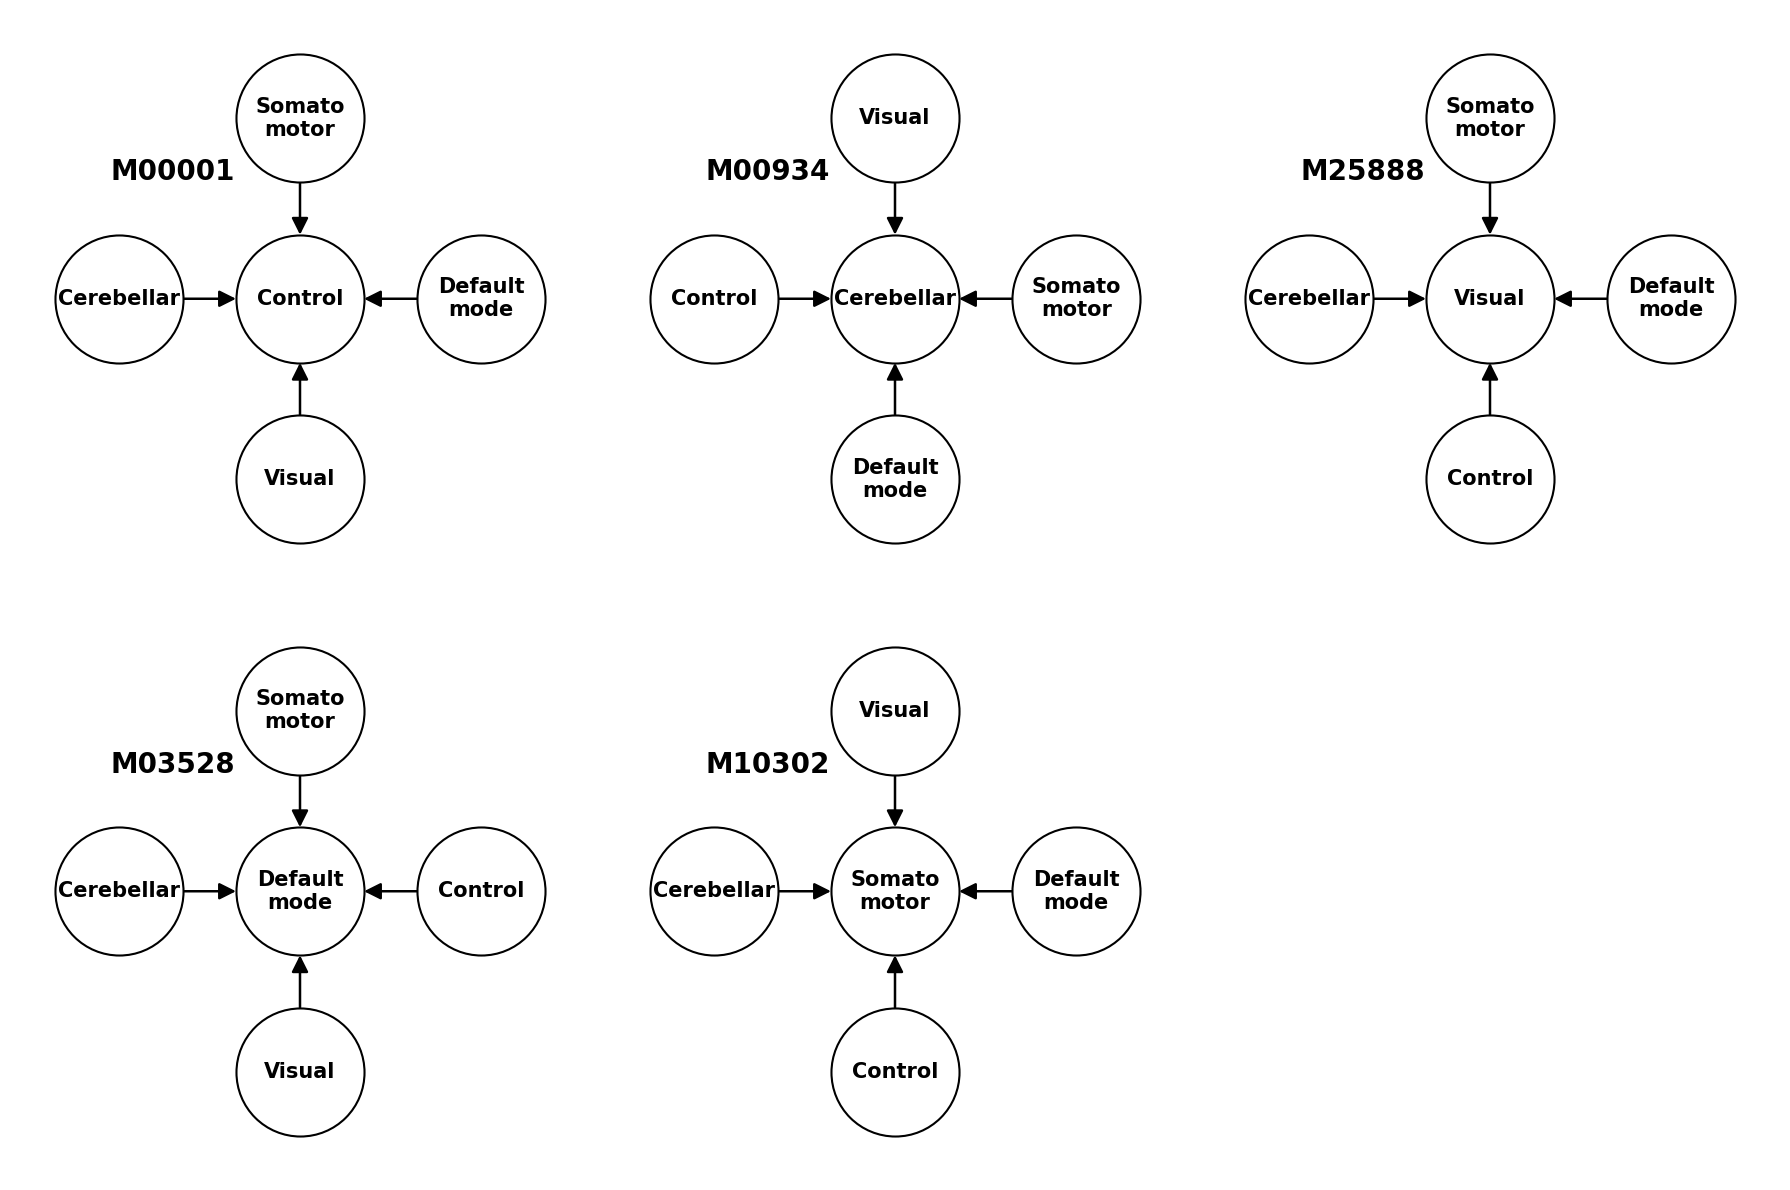

In [12]:
import networkx as nx
import matplotlib.pyplot as plt
import os

# 1. Definição dos dados para cada um dos 5 grafos
# Formato: (Identificador, Centro, Topo, Direita, Baixo, Esquerda)
dados_grafos = [
    ("M00001", "Control", "Somato\nmotor", "Default\nmode", "Visual", "Cerebellar"),
    ("M00934", "Cerebellar", "Visual", "Somato\nmotor", "Default\nmode", "Control"),
    ("M25888", "Visual", "Somato\nmotor", "Default\nmode", "Control", "Cerebellar"),
    ("M03528", "Default\nmode", "Somato\nmotor", "Control", "Visual", "Cerebellar"),
    ("M10302", "Somato\nmotor", "Visual", "Default\nmode", "Control", "Cerebellar")
]

# 2. Configuração da figura com subplots (2 linhas e 3 colunas)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten() # Transforma a matriz de eixos numa lista simples

for i, dados in enumerate(dados_grafos):
    id_grafo, centro, topo, direita, baixo, esquerda = dados
    ax = axes[i]
    
    # Cria o grafo direcionado
    G = nx.DiGraph()
    
    # Adiciona as arestas (todas apontando para o nó central)
    arestas = [
        (topo, centro),
        (direita, centro),
        (baixo, centro),
        (esquerda, centro)
    ]
    G.add_edges_from(arestas)
    
    # Define as posições fixas (formato de cruz)
    posicao = {
        centro: (0, 0),
        topo: (0, 1),
        direita: (1, 0),
        baixo: (0, -1),
        esquerda: (-1, 0)
    }
    
    # Desenha o grafo no subplot correspondente
    nx.draw(
        G, posicao, ax=ax,
        with_labels=True,
        node_size=8500, 
        node_color="white",
        edgecolors="black",
        linewidths=1.5,
        width=1.8,
        arrowsize=25,
        font_size=15, 
        font_weight="bold" # No NetworkX usa-se com underline
    )
    
    # CORREÇÃO AQUI: fontweight='bold' (sem underline) para o Matplotlib
    ax.text(-0.7, 0.7, id_grafo, 
            color='black', 
            fontsize=20, 
            fontweight='bold', 
            ha='center', va='center')
    
    # Ajusta os limites para garantir que os círculos não sejam cortados
    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-1.6, 1.6)
    
    # Remove os eixos do subplot
    ax.axis('off')

# 3. Remove o último subplot que ficou vazio (o 6º espaço)
axes[5].axis('off')

plt.tight_layout()

# 4. Salvar o ficheiro no caminho especificado
caminho = "../resultados/figuras/modelos_sem"
if not os.path.exists(caminho):
    os.makedirs(caminho)

plt.savefig(f"{caminho}/grafos_modelos.pdf", format="pdf")
plt.show()

### Plotagens parar escolha de feature:

In [2]:
# =========================================================
# 1. FUNÇÕES DE BASE
# =========================================================

def generate_logits(R: int, noise_type: str):
    if noise_type == "uniform": raw = np.random.uniform(0, 1, size=R)
    elif noise_type == "chi_square": raw = np.random.chisquare(df=2, size=R)
    elif noise_type == "exponential": raw = np.random.exponential(scale=1.0, size=R)
    elif noise_type == "laplace": raw = np.random.laplace(loc=0, scale=1, size=R)
    elif noise_type == "logistic": raw = np.random.logistic(loc=0, scale=1, size=R)
    elif noise_type == "student_t": raw = np.random.standard_t(df=3, size=R)
    elif noise_type == "F": raw = np.random.f(dfnum=5, dfden=10, size=R)
    elif noise_type == "gaussian": raw = np.random.normal(loc=0, scale=1, size=R)
    else: raise ValueError("Ruído desconhecido")
    return (raw - np.mean(raw))/np.std(raw)

def gerar_estrutura_causal_logits(R, tipo_ruido, estrutura_causal):
    def logistic(vetor): return 1 / (1 + np.exp(-vetor))
    ruido_A = generate_logits(R, tipo_ruido)
    ruido_B = generate_logits(R, tipo_ruido)

    if estrutura_causal == {"A->B"}:
        A = 0.5 * generate_logits(R, tipo_ruido) + ruido_A
        B = 0.5 * A + ruido_B
        return logistic(A), logistic(B)
    
    elif estrutura_causal == {"A<->B"}:
        ruido_A = generate_logits(R, tipo_ruido)
        ruido_B = generate_logits(R, tipo_ruido)

        A = 0.5 * generate_logits(R, tipo_ruido) + ruido_A
        B = 0.5 * generate_logits(R, tipo_ruido) + ruido_B
        return logistic(A), logistic(B)
    
    elif estrutura_causal == {"A->B", "A->C"}:
        ruido_B = generate_logits(R, tipo_ruido)
        ruido_C = generate_logits(R, tipo_ruido)

        A = generate_logits(R, tipo_ruido)
        B = 0.5 * A + ruido_B
        C = -0.5 * A + ruido_C
        return logistic(A), logistic(B), logistic(C)
    
    return None

def param_er(logit): return logit
def graph_gen_er(n, p): return ig.Graph.Erdos_Renyi(n=n, p=p, directed=False)

def param_ge(logit): return logit
def graph_gen_geo(n, r): return ig.Graph.GRG(n, radius=r)

def param_kr(logit): return (logit * 10).astype(int)
def graph_gen_kreg(n, k):
    if k >= n: k = n - 1 
    if (n * k) % 2 != 0: k -= 1 
    if k < 1: k = 2 if n % 2 == 0 else (2 if (n*2)%2==0 else 0)
    try: return ig.Graph.K_Regular(n, k)
    except: return ig.Graph()

def param_ba(logit): return 2 * logit
def graph_gen_ba(n, p): return ig.Graph.Barabasi(n=n, m=1, power=p, directed=False)

def param_ws(logit): return logit
def graph_gen_ws(n, p_w): return ig.Graph.Watts_Strogatz(dim=1, size=n, nei=3, p=p_w)

def get_lam_and_evc(graph):
    if graph.ecount() == 0: return 0.0, 0.0
    try:
        evc, lam = graph.eigenvector_centrality(return_eigenvalue=True)
        return float(lam), float(np.mean(evc))
    except:
        adj_matrix = np.array(graph.get_adjacency().data)
        eigenvalues, eigenvectors = np.linalg.eigh(adj_matrix)
        max_idx = np.argmax(np.abs(eigenvalues))
        return float(np.abs(eigenvalues[max_idx])), float(np.mean(np.abs(eigenvectors[:, max_idx])))

def extract_graph_features(graph):
    n = graph.vcount()
    tc = graph.transitivity_undirected(mode="nan")
    if np.isnan(tc): tc = 0.0
    bc = np.mean(graph.betweenness(directed=False)).item()
    cc = np.mean(graph.closeness(mode="all", normalized=True)).item()
    if np.isnan(cc): cc = 0.0
    dc = (np.mean(graph.degree()) / (n - 1)).item() if n > 1 else 0.0
    
    try:
        as_coef = graph.assortativity_degree(directed=False)
        if np.isnan(as_coef): as_coef = 0.0
    except: as_coef = 0.0
        
    sr, evc = get_lam_and_evc(graph)
    return {r'$\lambda_1$': sr, 'TC': tc, 'BC': bc, 'CC': cc, 'EVC': evc, 'DC': dc, 'AS': as_coef}


def gerar_amostras_grafos(modelo, n_v, R, *logits):
    if len(logits) == 2:
        A_logits = logits[0]
        B_logits = logits[1]
        lista_A, lista_B = [], []
        for j in range(R):
            if modelo == "erdos_renyi": G_A = graph_gen_er(n=n_v, p=param_er(A_logits[j])); G_B = graph_gen_er(n=n_v, p=param_er(B_logits[j]))
            elif modelo == "barabasi_albert": G_A = graph_gen_ba(n=n_v, p=param_ba(A_logits[j])); G_B = graph_gen_ba(n=n_v, p=param_ba(B_logits[j]))
            elif modelo == "geometric": G_A = graph_gen_geo(n=n_v, r=param_ge(A_logits[j])); G_B = graph_gen_geo(n=n_v, r=param_ge(B_logits[j]))
            elif modelo == "k_regular": G_A = graph_gen_kreg(n=n_v, k=param_kr(A_logits[j])); G_B = graph_gen_kreg(n=n_v, k=param_kr(B_logits[j]))
            elif modelo == "watts_strogatz": G_A = graph_gen_ws(n=n_v, p_w=param_ws(A_logits[j])); G_B = graph_gen_ws(n=n_v, p_w=param_ws(B_logits[j]))
                
            lista_A.append(extract_graph_features(G_A))
            lista_B.append(extract_graph_features(G_B))
        return pd.DataFrame(lista_A), pd.DataFrame(lista_B)
    
    elif len(logits) == 3:
        A_logits = logits[0]
        B_logits = logits[1]
        C_logits = logits[2]
        lista_A, lista_B, lista_C = [], [], []
        for j in range(R):
            if modelo == "erdos_renyi": G_A = graph_gen_er(n=n_v, p=param_er(A_logits[j])); G_B = graph_gen_er(n=n_v, p=param_er(B_logits[j])); G_C = graph_gen_er(n=n_v, p=param_er(C_logits[j]))
            elif modelo == "barabasi_albert": G_A = graph_gen_ba(n=n_v, p=param_ba(A_logits[j])); G_B = graph_gen_ba(n=n_v, p=param_ba(B_logits[j])); G_C = graph_gen_ba(n=n_v, p=param_ba(C_logits[j]))
            elif modelo == "geometric": G_A = graph_gen_geo(n=n_v, r=param_ge(A_logits[j])); G_B = graph_gen_geo(n=n_v, r=param_ge(B_logits[j])); G_C = graph_gen_geo(n=n_v, r=param_ge(C_logits[j]))
            elif modelo == "k_regular": G_A = graph_gen_kreg(n=n_v, k=param_kr(A_logits[j])); G_B = graph_gen_kreg(n=n_v, k=param_kr(B_logits[j])); G_C = graph_gen_kreg(n=n_v, k=param_kr(C_logits[j]))
            elif modelo == "watts_strogatz": G_A = graph_gen_ws(n=n_v, p_w=param_ws(A_logits[j])); G_B = graph_gen_ws(n=n_v, p_w=param_ws(B_logits[j])); G_C = graph_gen_ws(n=n_v, p_w=param_ws(C_logits[j]))
                
            lista_A.append(extract_graph_features(G_A))
            lista_B.append(extract_graph_features(G_B))
            lista_C.append(extract_graph_features(G_C))
        return pd.DataFrame(lista_A), pd.DataFrame(lista_B), pd.DataFrame(lista_C)



def parse_pvalue(p_val_raw):
    if pd.isna(p_val_raw) or p_val_raw == "-": return 1.0
    if isinstance(p_val_raw, str):
        if "<" in p_val_raw: return 0.0
        try: return float(p_val_raw)
        except: return 1.0
    return float(p_val_raw)

#### 1) Plot Correlações entre parâmetro gerador e feature:

Iniciando bateria de simulações com distribuições independentes...

Simulando modelo: Erdös-Rényi
  -> Processando n=25...
  -> Processando n=50...
  -> Processando n=75...
  -> Processando n=100...

Simulando modelo: Geometric
  -> Processando n=25...
  -> Processando n=50...
  -> Processando n=75...
  -> Processando n=100...

Simulando modelo: K-regular
  -> Processando n=25...
  -> Processando n=50...
  -> Processando n=75...
  -> Processando n=100...

Simulando modelo: Barabási-Albert
  -> Processando n=25...
  -> Processando n=50...
  -> Processando n=75...
  -> Processando n=100...

Simulando modelo: Watts-Strogatz
  -> Processando n=25...
  -> Processando n=50...
  -> Processando n=75...
  -> Processando n=100...

Simulações concluídas. Gerando grade de subplots...


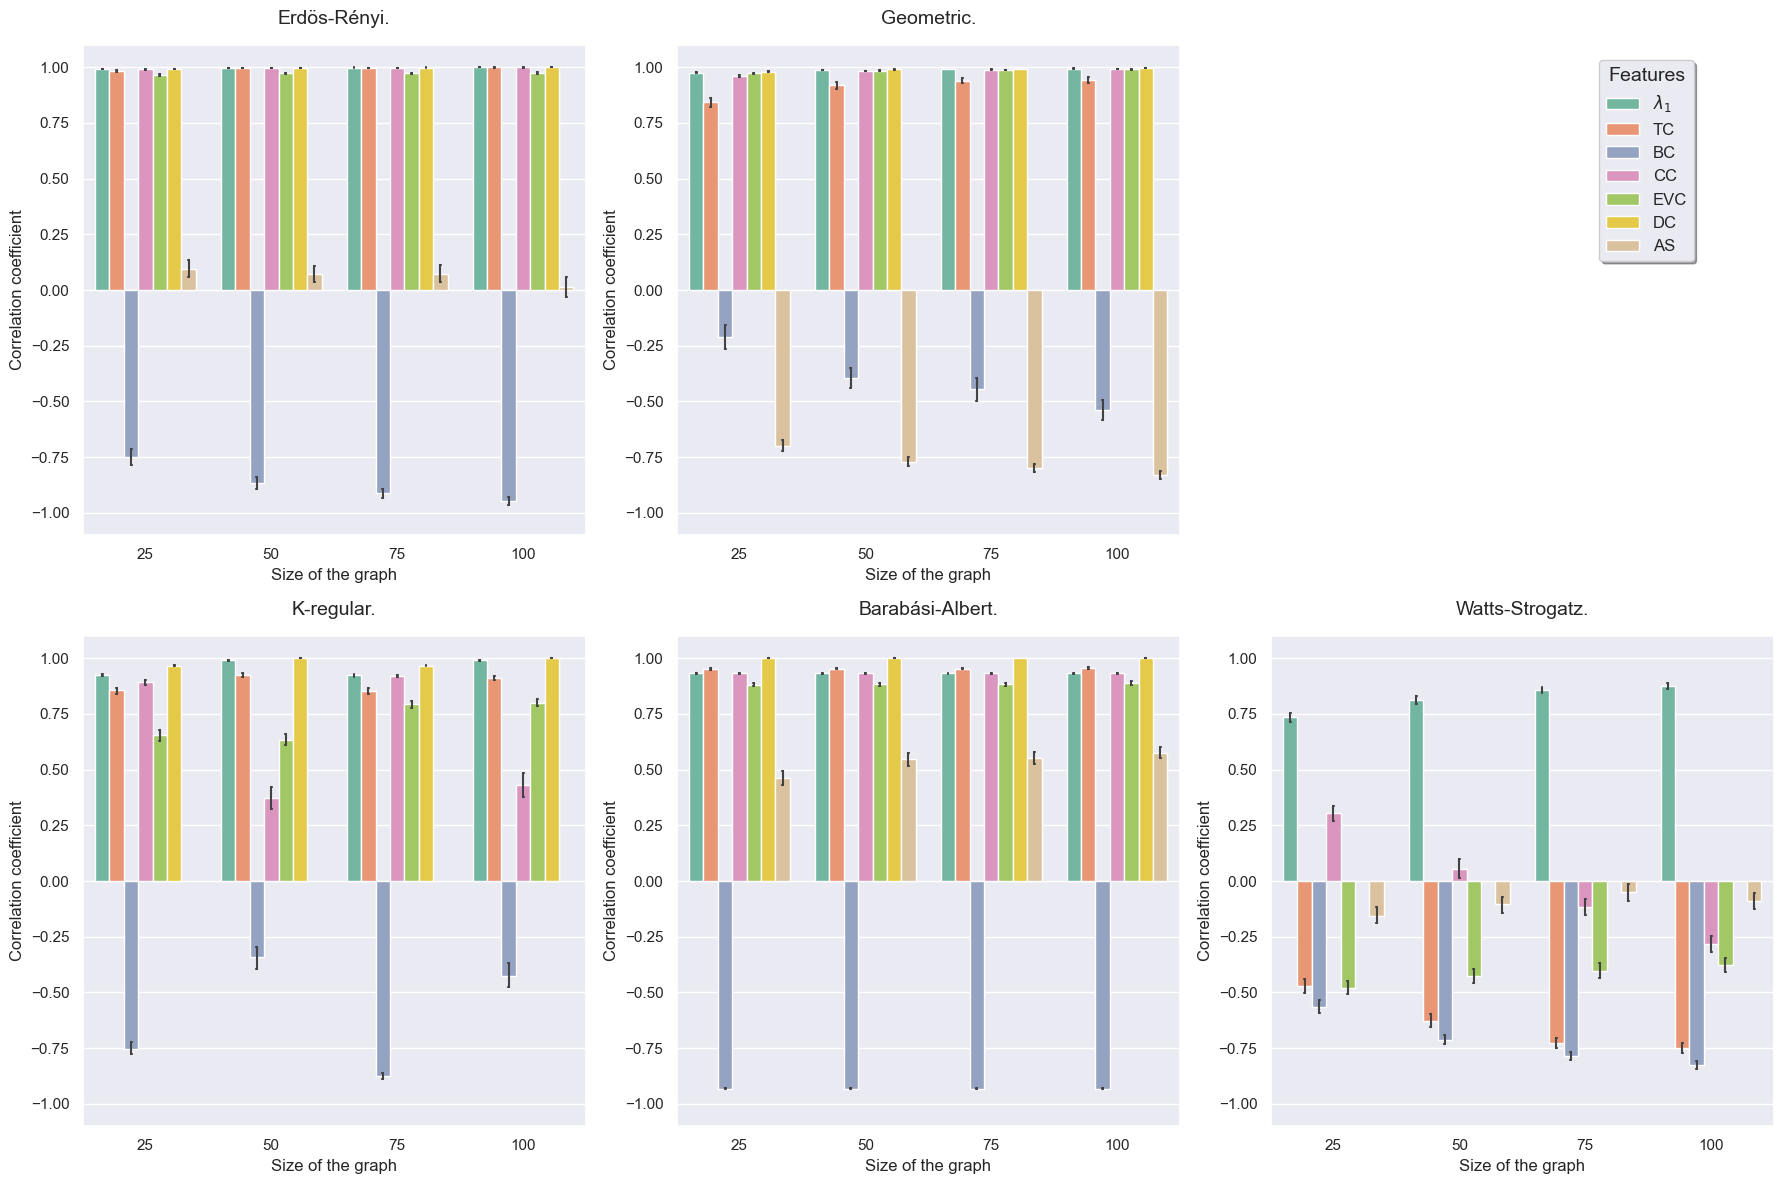

In [3]:
import igraph as ig
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suprime avisos do matplotlib/seaborn e do motor de cálculo de autovalores
warnings.filterwarnings("ignore")

# =====================================================================
# 1. FUNÇÕES DE EXTRAÇÃO DE FEATURES
# =====================================================================

def get_lam_and_evc(graph):
    """Calcula Raio Espectral (λ) e Centralidade de Autovetor (EVC)."""
    if graph.ecount() == 0:
        return 0.0, 0.0
    
    try:
        evc, lam = graph.eigenvector_centrality(return_eigenvalue=True)
        return float(lam), float(np.mean(evc))
    except Exception:
        # Fallback de segurança para grafos desconexos onde o ARPACK falha
        adj_matrix = np.array(graph.get_adjacency().data)
        eigenvalues, eigenvectors = np.linalg.eigh(adj_matrix)
        max_idx = np.argmax(np.abs(eigenvalues))
        lam = float(np.abs(eigenvalues[max_idx]))
        evc_mean = float(np.mean(np.abs(eigenvectors[:, max_idx])))
        return lam, evc_mean

def extract_graph_features(graph):
    """Calcula as topologias do grafo em um único passo, incluindo Assortatividade."""
    n = graph.vcount()
    
    tc = graph.transitivity_undirected(mode="nan")
    if np.isnan(tc): tc = 0.0
    
    bc = np.mean(graph.betweenness(directed=False))
    
    cc = np.mean(graph.closeness(mode="all", normalized=True))
    if np.isnan(cc): cc = 0.0
        
    if n > 1:
        dc = np.mean(graph.degree()) / (n - 1)
    else:
        dc = 0.0
        
    # Assortativity (AS)
    try:
        as_coef = graph.assortativity_degree(directed=False)
        if np.isnan(as_coef): as_coef = 0.0
    except Exception:
        as_coef = 0.0
        
    sr, evc = get_lam_and_evc(graph)
    
    # <--- ALTERADO AQUI: 'λ' substituído por r'$\lambda_1$'
    return {r'$\lambda_1$': sr, 'TC': tc, 'BC': bc, 'CC': cc, 'EVC': evc, 'DC': dc, 'AS': as_coef}

# =====================================================================
# 2. GERADORES DE PARÂMETROS E MODELOS (REFATORADO CONFORME IMAGEM)
# =====================================================================

# (a) Erdös-Rényi: p ~ U(0, 1)
def param_gen_er(n, n_points):
    return np.random.uniform(0, 1, n_points)
def graph_gen_er(n, p):
    return ig.Graph.Erdos_Renyi(n=n, p=p, directed=False)

# (b) Geometric: r ~ U(0, 1)
def param_gen_geo(n, n_points):
    return np.random.uniform(0, 1, n_points)
def graph_gen_geo(n, r):
    return ig.Graph.GRG(n, radius=r)

# (c) Regular: k ~ integer part of U(1, 10)
def param_gen_kreg(n, n_points):
    return np.floor(np.random.uniform(1, 10, n_points)).astype(int)
def graph_gen_kreg(n, k):
    # Regras de segurança matemática para grafos regulares
    if k >= n: k = n - 1 
    if (n * k) % 2 != 0: k -= 1 
    if k < 1: k = 2 if n % 2 == 0 else (2 if (n*2)%2==0 else 0)
    
    try:
        return ig.Graph.K_Regular(n, k)
    except:
        return ig.Graph()

# (d) Barabási-Albert: p_s ~ integer part of U(1, 4)
def param_gen_ba(n, n_points):
    return np.floor(np.random.uniform(1, 4, n_points)).astype(int)
def graph_gen_ba(n, m):
    # m é o número de arestas adicionadas por passo (que na legenda anterior era função de p)
    m = int(m)
    return ig.Graph.Barabasi(n=n, m=m, directed=False)

# (e) Watts-Strogatz: pw ~ U(0, 1)
def param_gen_ws(n, n_points):
    return np.random.uniform(0, 1, n_points)
def graph_gen_ws(n, p_w):
    return ig.Graph.Watts_Strogatz(dim=1, size=n, nei=2, p=p_w)

# =====================================================================
# 3. NÚCLEO DA SIMULAÇÃO
# =====================================================================

def run_simulation(graph_generator_func, param_generator_func, sizes, n_iterations, n_points):
    resultados = []
    
    for n in sizes:
        print(f"  -> Processando n={n}...")
        for _ in range(n_iterations):
            
            parametros = param_generator_func(n, n_points)
            
            # <--- ALTERADO AQUI: 'λ' substituído por r'$\lambda_1$' no dicionário inicial
            vetores_features = {r'$\lambda_1$': [], 'TC': [], 'BC': [], 'CC': [], 'EVC': [], 'DC': [], 'AS': []}
            vetor_param_atual = []
            
            for param in parametros:
                G = graph_generator_func(n, param)
                
                if G.ecount() == 0: 
                    continue
                    
                vetor_param_atual.append(param)
                
                features = extract_graph_features(G)
                for key in vetores_features:
                    vetores_features[key].append(features[key])
            
            if len(vetor_param_atual) > 1:
                for feature_name, feature_vector in vetores_features.items():
                    # Evitar correlações com vetor constante
                    if np.std(feature_vector) > 1e-9 and np.std(vetor_param_atual) > 1e-9:
                        corr, _ = spearmanr(vetor_param_atual, feature_vector)
                        resultados.append({
                            'Size of the graph': n,
                            'Feature': feature_name,
                            'Correlation coefficient': corr
                        })
                        
    return pd.DataFrame(resultados)

# =====================================================================
# 4. EXECUTANDO E PLOTANDO
# =====================================================================

if __name__ == "__main__":
    tamanhos = [25, 50, 75, 100]
    
    # ATUALIZADO CONFORME A IMAGEM
    iteracoes = 100     
    pontos_por_iteracao = 30 # "number of graphs was set to k = 30"
    
    modelos = [
        ("Erdös-Rényi", param_gen_er, graph_gen_er),
        ("Geometric", param_gen_geo, graph_gen_geo),
        ("K-regular", param_gen_kreg, graph_gen_kreg),
        ("Barabási-Albert", param_gen_ba, graph_gen_ba),
        ("Watts-Strogatz", param_gen_ws, graph_gen_ws)
    ]
    
    resultados_finais = {}
    
    print("Iniciando bateria de simulações com distribuições independentes...")
    for nome, param_gen, graph_gen in modelos:
        print(f"\nSimulando modelo: {nome}")
        df = run_simulation(graph_gen, param_gen, tamanhos, iteracoes, pontos_por_iteracao)
        resultados_finais[nome] = df
        
    print("\nSimulações concluídas. Gerando grade de subplots...")

    sns.set_theme(style="darkgrid")
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    axes[2].set_visible(False) 
    
    ax_map = [axes[0], axes[1], axes[3], axes[4], axes[5]]
    
    # <--- ALTERADO AQUI: 'λ' substituído por r'$\lambda_1$' na ordem de plotagem
    feature_order = [r'$\lambda_1$', 'TC', 'BC', 'CC', 'EVC', 'DC', 'AS']
    
    for i, (nome, df_model) in enumerate(resultados_finais.items()):
        ax = ax_map[i]
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            sns.barplot(
                data=df_model, 
                x='Size of the graph', 
                y='Correlation coefficient', 
                hue='Feature',
                hue_order=feature_order,
                capsize=.05, 
                errwidth=1.5,
                palette="Set2",
                ax=ax
            )
        
        ax.set_title(f"{nome}.", pad=15, fontsize=14, loc='center')
        ax.set_ylabel('Correlation coefficient')
        ax.set_ylim(-1.1, 1.1)
        
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    handles, labels = ax_map[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.95, 0.95), 
               title="Features", fontsize=12, title_fontsize=14, frameon=True, shadow=True)

    plt.tight_layout()
    plt.show()

#### 2) Plot Poder de detecção de aresta

##### Caso 1 e 2

In [9]:

# Silencia os avisos internos do semopy para não poluir o terminal
logging.getLogger('semopy').setLevel(logging.ERROR)

# =========================================================
# 2. EXPERIMENTO DE PODER ESTATÍSTICO (MONTE CARLO)
# =========================================================

R = 50               
N_SIMS = 1000           # Alterado para 10 conforme solicitado
alpha = 0.05          
ruido = "uniform"
caso = "Caso_2"
estrutura = {"A->B"}

vertices_list = [25, 50, 100] 
modelos = ["erdos_renyi", "geometric", "barabasi_albert", "k_regular", "watts_strogatz"]
features = [r"$\lambda_1$", "TC", "BC", "CC", "EVC", "DC", "AS"]

resultados_power = []
lista_p_valores = [] # Lista para acumular todos os p-valores da simulação

print(f"Iniciando simulações de Monte Carlo para cálculo de Poder ({N_SIMS} simulações)...")

for modelo in modelos:
    for n_v in vertices_list:
        print(f"➜ Processando: Modelo = {modelo.upper():<16} | Vértices = {n_v}")
        
        # Dicionário aninhado para rastrear o poder nas duas direções
        sucessos_rejeicao = {
            "A->B": {feat: 0 for feat in features},
            "B->A": {feat: 0 for feat in features}
        }
        
        for sim in range(N_SIMS):
            # Presume-se que as funções abaixo já estejam definidas no seu ambiente
            A, B = gerar_estrutura_causal_logits(R, ruido, estrutura)
            df_A, df_B = gerar_amostras_grafos(modelo, n_v, R, A, B)
            
            for feature in features:
                # Tradução segura do nome para não quebrar o parser do semopy
                safe_feat_name = feature.replace(r"$\lambda_1$", "Lambda").replace("$", "").replace("\\", "").replace("_", "")
                col_A = f"{safe_feat_name}_A"
                col_B = f"{safe_feat_name}_B"
                
                df_merged = pd.concat([df_A[feature].rename(col_A), 
                                       df_B[feature].rename(col_B)], axis=1)

                # Trava de segurança: se a variância for quase nula, salva como Nulo (None) e pula
                if df_merged[col_A].std() < 1e-5 or df_merged[col_B].std() < 1e-5:
                    lista_p_valores.append({"Modelo": modelo, "Vertices": n_v, "Feature": feature, "Direcao": "A->B", "Simulacao": sim, "p_valor": None})
                    lista_p_valores.append({"Modelo": modelo, "Vertices": n_v, "Feature": feature, "Direcao": "B->A", "Simulacao": sim, "p_valor": None})
                    continue

                # Padronização (Z-Score)
                stds = df_merged.std()
                df_merged = (df_merged - df_merged.mean()) / stds
                
                # Definir os dois modelos (as duas direções)
                modelos_sem = {
                    "A->B": {"formula": f"{col_B} ~ {col_A}", "lval": col_B, "rval": col_A},
                    "B->A": {"formula": f"{col_A} ~ {col_B}", "lval": col_A, "rval": col_B}
                }
                
                for direcao, detalhes in modelos_sem.items():
                    p_value = None # Inicializa como nulo caso dê erro de convergência no semopy
                    
                    try:
                        model_sem = semopy.Model(detalhes["formula"])
                        model_sem.fit(df_merged)
                        ins = model_sem.inspect()
                        
                        # Extrai exatamente a linha da relação que estamos testando
                        row = ins[(ins['lval'] == detalhes["lval"]) & (ins['rval'] == detalhes["rval"])]
                        
                        if not row.empty:
                            pval_raw = row['p-value'].values[0]
                            p_value = float(pval_raw.replace('<', '').strip()) if isinstance(pval_raw, str) else float(pval_raw)
                            
                            if p_value < alpha:
                                sucessos_rejeicao[direcao][feature] += 1
                                
                    except Exception:
                        pass # Ignora erros de convergência; p_value continua como None
                    
                    # Garante que a simulação SEMPRE registre uma linha (com valor numérico ou None)
                    lista_p_valores.append({
                        "Modelo": modelo,
                        "Vertices": n_v,
                        "Feature": feature,
                        "Direcao": direcao,
                        "Simulacao": sim,
                        "p_valor": p_value
                    })
                
        # Consolidando os resultados de Poder
        for feature in features:
            poder_A_B = sucessos_rejeicao["A->B"][feature] / N_SIMS
            poder_B_A = sucessos_rejeicao["B->A"][feature] / N_SIMS
            
            resultados_power.append({
                "Modelo": modelo, "Vértices": n_v, "Feature": feature, "Direcao": "A->B", "Poder": poder_A_B
            })
            resultados_power.append({
                "Modelo": modelo, "Vértices": n_v, "Feature": feature, "Direcao": "B->A", "Poder": poder_B_A
            })

# =========================================================
# 3. EXPORTAÇÃO E ORGANIZAÇÃO DOS ARQUIVOS
# =========================================================

# 1. Preparando diretórios
path_dir = os.path.join("..", "dados", "dados_plots", "simulacao_1", caso)
path_p_valores = os.path.join(path_dir, "p_valores")
os.makedirs(path_p_valores, exist_ok=True)

# 2. Salvando resultados gerais de Poder
df_resultados = pd.DataFrame(resultados_power)

# Configurações visuais (opcional para display)
sns.set_theme(style="darkgrid")
titulos_formatados = {
    "erdos_renyi": "Erdös-Rényi",
    "geometric": "Geometric",
    "k_regular": "K-regular",
    "barabasi_albert": "Barabási-Albert",
    "watts_strogatz": "Watts-Strogatz"
}
mapa_titulos = {mod: titulos_formatados.get(mod, mod) for mod in modelos}
df_resultados['Titulo_Subplot'] = df_resultados['Modelo'].map(mapa_titulos)
display(df_resultados)

path_resultados = os.path.join(path_dir, f"poder_features_{ruido}_R{R}.csv")
df_resultados.to_csv(path_resultados, index=False)
print(f"\n✅ Resultados de Poder salvos em: {path_resultados}")

# 3. Salvando p-valores individualmente por Vértice e Feature
df_p_total = pd.DataFrame(lista_p_valores)

print(f"📂 Salvando arquivos individuais de p-valores em: {path_p_valores}...")

for n_v in vertices_list:
    for feat in features:
        # Filtra o DataFrame para a combinação atual
        df_filtro = df_p_total[(df_p_total['Vertices'] == n_v) & (df_p_total['Feature'] == feat)]
        
        if not df_filtro.empty:
            # Limpa o nome da feature para o nome do arquivo (remove $, \, e lambda)
            clean_feat_name = feat.replace(r"$\lambda_1$", "Lambda1").replace("$", "").replace("\\", "").replace("_", "")
            
            nome_arquivo = f"p_valores_N{n_v}_{clean_feat_name}.csv"
            caminho_final = os.path.join(path_p_valores, nome_arquivo)
            
            df_filtro.to_csv(caminho_final, index=False)

print("✅ Todos os arquivos de p-valores foram gerados com sucesso e com a contagem exata de simulações.")

Iniciando simulações de Monte Carlo para cálculo de Poder (1000 simulações)...
➜ Processando: Modelo = ERDOS_RENYI      | Vértices = 25
➜ Processando: Modelo = ERDOS_RENYI      | Vértices = 50
➜ Processando: Modelo = ERDOS_RENYI      | Vértices = 100
➜ Processando: Modelo = GEOMETRIC        | Vértices = 25
➜ Processando: Modelo = GEOMETRIC        | Vértices = 50
➜ Processando: Modelo = GEOMETRIC        | Vértices = 100
➜ Processando: Modelo = BARABASI_ALBERT  | Vértices = 25
➜ Processando: Modelo = BARABASI_ALBERT  | Vértices = 50
➜ Processando: Modelo = BARABASI_ALBERT  | Vértices = 100
➜ Processando: Modelo = K_REGULAR        | Vértices = 25
➜ Processando: Modelo = K_REGULAR        | Vértices = 50
➜ Processando: Modelo = K_REGULAR        | Vértices = 100
➜ Processando: Modelo = WATTS_STROGATZ   | Vértices = 25
➜ Processando: Modelo = WATTS_STROGATZ   | Vértices = 50
➜ Processando: Modelo = WATTS_STROGATZ   | Vértices = 100


,Modelo,Vértices,Feature,Direcao,Poder,Titulo_Subplot
0,erdos_renyi,25,$\lambda_1$,A->B,0.950,Erdös-Rényi
1,erdos_renyi,25,$\lambda_1$,B->A,0.950,Erdös-Rényi
2,erdos_renyi,25,TC,A->B,0.952,Erdös-Rényi
3,erdos_renyi,25,TC,B->A,0.952,Erdös-Rényi
4,erdos_renyi,25,BC,A->B,0.865,Erdös-Rényi
...,...,...,...,...,...,...
205,watts_strogatz,100,EVC,B->A,0.164,Watts-Strogatz
206,watts_strogatz,100,DC,A->B,0.000,Watts-Strogatz
207,watts_strogatz,100,DC,B->A,0.000,Watts-Strogatz
208,watts_strogatz,100,AS,A->B,0.064,Watts-Strogatz



✅ Resultados de Poder salvos em: ..\dados\dados_plots\simulacao_1\Caso_2\poder_features_uniform_R50.csv
📂 Salvando arquivos individuais de p-valores em: ..\dados\dados_plots\simulacao_1\Caso_2\p_valores...
✅ Todos os arquivos de p-valores foram gerados com sucesso e com a contagem exata de simulações.


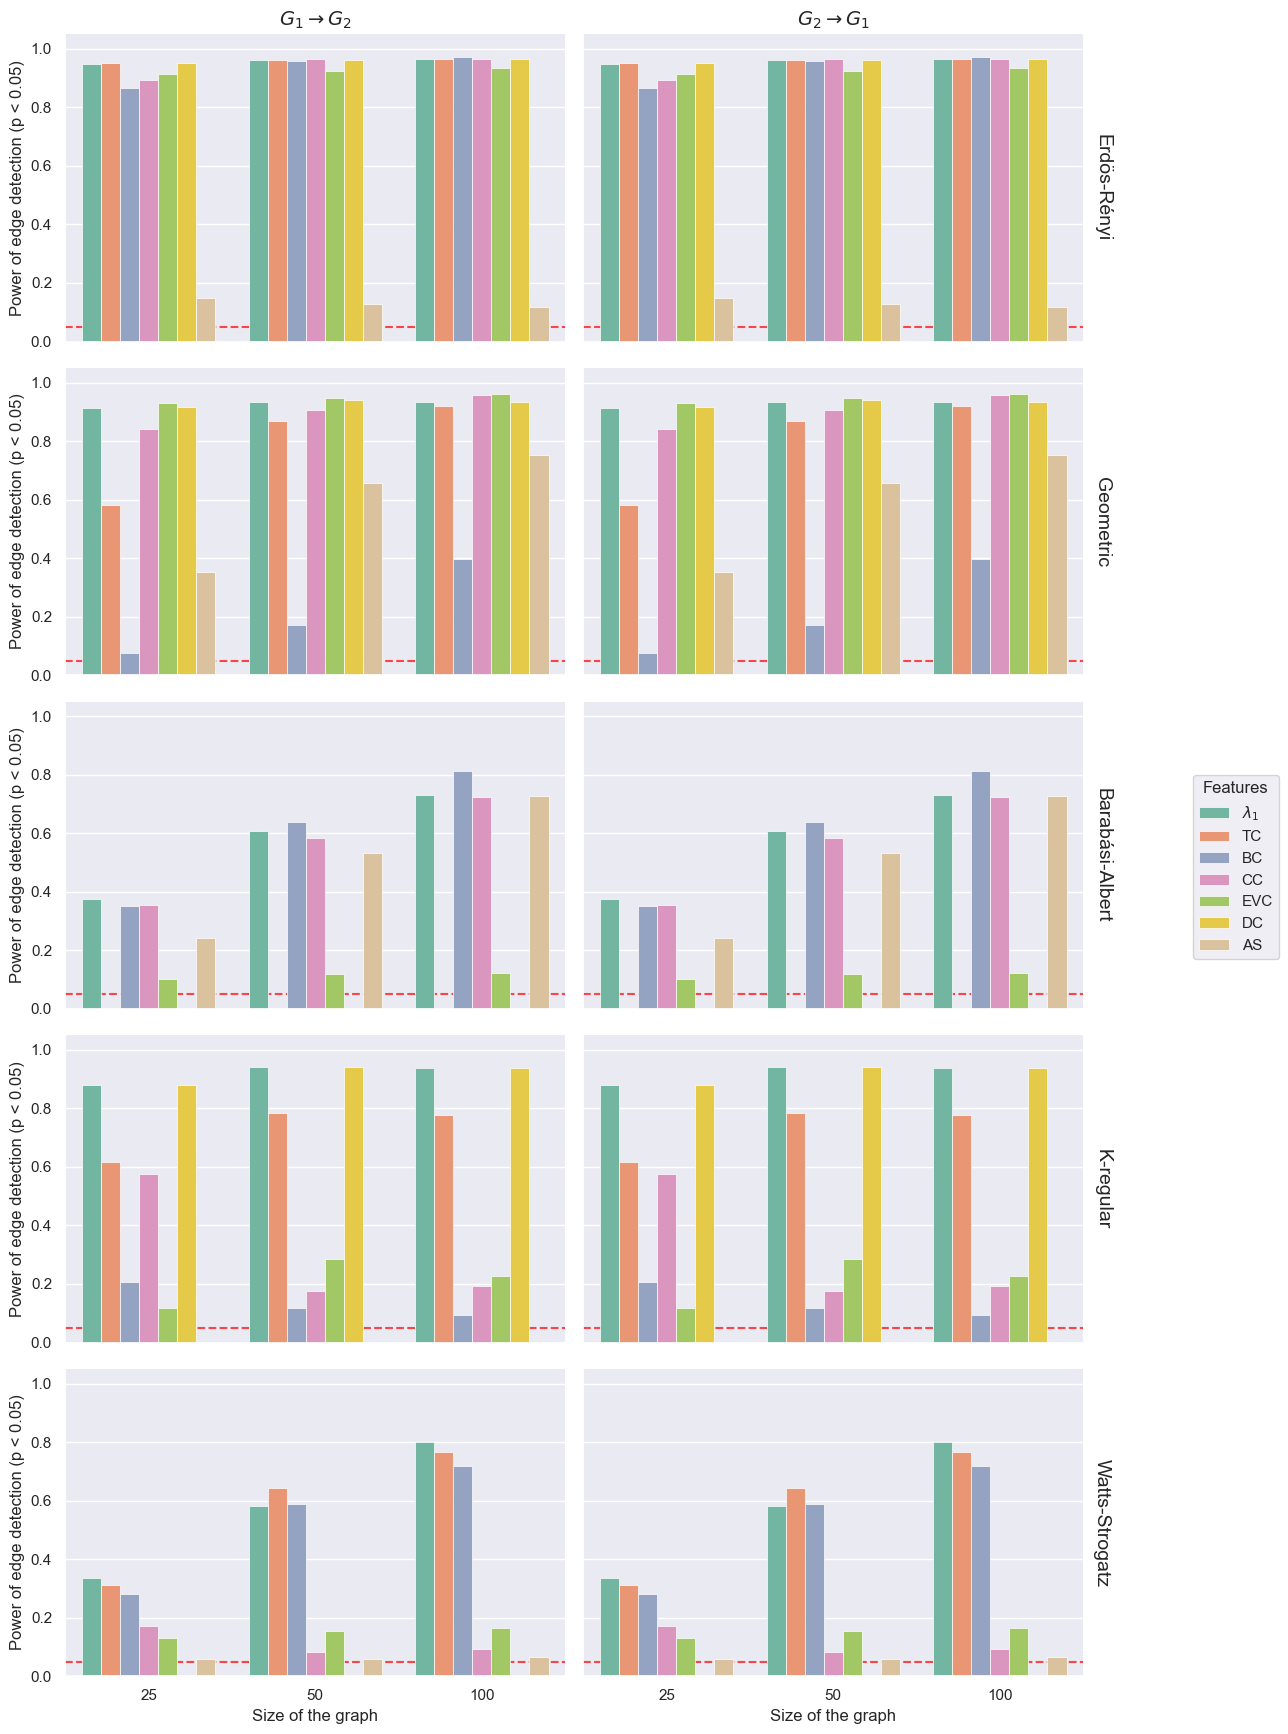

Arquivo salvo como: plot_poder_features_uniform_Caso_2_Matriz.pdf


In [11]:
# Supondo que ruido, R, caso e features já estejam definidos no seu script
# ruido = "uniform"
# R = 50
# features = [r"$\lambda_1$", "TC", "BC", "CC", "EVC", "DC", "AS"]
caso = "Caso_2"

path_dir = os.path.join("..", "dados", "dados_plots", "simulacao_1", caso) # Ajuste se necessário
path_resultados = os.path.join(path_dir, f"poder_features_{ruido}_R{R}.csv")
df_resultados = pd.read_csv(path_resultados)

# 1. Traduzindo as direções para o formato Matemático (LaTeX)
mapa_direcoes = {
    "A->B": r"$G_1 \to G_2$",
    "B->A": r"$G_2 \to G_1$"
}
# Cria a coluna que vai guiar o eixo X (colunas do grid)
df_resultados['Direcao_Formatada'] = df_resultados['Direcao'].map(mapa_direcoes)

# 2. Aplicando o tema cinza com grid branco
sns.set_theme(style="darkgrid")

# 3. Definindo a paleta de cores 
paleta_cores = sns.color_palette("Set2", n_colors=len(features))

# 4. Gerando os gráficos facetados em Matriz (Linhas x Colunas)
g = sns.catplot(
    data=df_resultados,
    x="Vértices",             
    y="Poder",                
    hue="Feature",            
    col="Direcao_Formatada",  # Colunas representam a Direção Causal
    row="Titulo_Subplot",     # Linhas representam os Modelos de Grafos
    kind="bar",
    height=3.5,               # Altura reduzida para caber os 5 modelos na página
    aspect=1.5,               # Deixa as barras mais "esticadas" horizontalmente
    palette=paleta_cores,     
    edgecolor="white",        
    linewidth=0.5,
    margin_titles=True        # Coloca os nomes das linhas na lateral direita, economizando espaço
)

# 5. Ajustando títulos e eixos
g.set_axis_labels("Size of the graph", "Power of edge detection (p < 0.05)")

# Formata os títulos para remover "Direcao_Formatada =" e "Titulo_Subplot ="
g.set_titles(col_template="{col_name}", row_template="{row_name}", size=14)

# ==============================================================================
# 5.1 Adicionando a linha tracejada de Erro Tipo I (0.05) na direção G2 -> G1
# ==============================================================================
for (row_val, col_val), ax in g.axes_dict.items():
    ax.axhline(0.05, color='red', linestyle='--', linewidth=1.5, alpha=0.7, zorder=0)

# 6. Movendo a Legenda para fora da área dos subplots
sns.move_legend(g, "center left", bbox_to_anchor=(1.05, 0.5), title="Features", frameon=True)

# 7. Forçando os limites do eixo Y para respirar até 1.05
for ax in g.axes.flatten():
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# 8. Salvamento
nome_arquivo = f"plot_poder_features_{ruido}_{caso}_Matriz.pdf"
path = os.path.join("..", "resultados", "figuras", caso, ruido)
os.makedirs(path, exist_ok=True)
g.savefig(os.path.join(path, nome_arquivo), format='pdf', bbox_inches='tight')
print(f"Arquivo salvo como: {nome_arquivo}")

##### Caso 3

In [13]:

# Silencia os avisos internos do semopy
logging.getLogger('semopy').setLevel(logging.ERROR)

# =========================================================
# 2. EXPERIMENTO (MONTE CARLO) - CASO 3 (Confounding)
# =========================================================

R = 50               
N_SIMS = 1000           # Alterado para 10 conforme sua solicitação anterior
alpha = 0.05          
ruido = "uniform"
caso = "Caso_3"
# Estrutura real de geração: A causa B e A causa C
estrutura = {"A->B", "A->C"} 

vertices_list = [25, 50, 100] 
modelos = ["erdos_renyi", "geometric", "barabasi_albert", "k_regular", "watts_strogatz"]
features = [r"$\lambda_1$", "TC", "BC", "CC", "EVC", "DC", "AS"]

resultados_power = []
lista_p_valores = [] # Lista para acumular todos os p-valores da simulação

print(f"Iniciando simulações de Monte Carlo para o Caso 3 (B <- A -> C) com {N_SIMS} simulações...")

for modelo in modelos:
    for n_v in vertices_list:
        print(f"➜ Processando: Modelo = {modelo.upper():<16} | Vértices = {n_v}")
        
        # Rastreando o ajuste para as 3 arestas do modelo SEM
        sucessos_rejeicao = {
            "A->B": {feat: 0 for feat in features}, # Esperado: Alto Poder (Verdadeiro Positivo)
            "A->C": {feat: 0 for feat in features}, # Esperado: Alto Poder (Verdadeiro Positivo)
            "B->C": {feat: 0 for feat in features}  # Esperado: ~0.05 (Controle de Erro Tipo I)
        }
        
        for sim in range(N_SIMS):
            # Presume-se que as funções abaixo já estejam definidas no seu ambiente
            A, B, C = gerar_estrutura_causal_logits(R, ruido, estrutura)
            df_A, df_B, df_C = gerar_amostras_grafos(modelo, n_v, R, A, B, C)
            
            for feature in features:
                # Nome seguro para o SEM (sem LaTeX)
                safe_feat_name = feature.replace(r"$\lambda_1$", "Lambda").replace("$", "").replace("\\", "").replace("_", "")
                col_A = f"{safe_feat_name}_A"
                col_B = f"{safe_feat_name}_B"
                col_C = f"{safe_feat_name}_C"
                
                # Concatenação segura das 3 variáveis
                df_merged = pd.concat([
                    df_A[feature].reset_index(drop=True).rename(col_A), 
                    df_B[feature].reset_index(drop=True).rename(col_B),
                    df_C[feature].reset_index(drop=True).rename(col_C)
                ], axis=1).dropna()

                if len(df_merged) < 5:
                    for aresta in ["A->B", "A->C", "B->C"]:
                        lista_p_valores.append({"Modelo": modelo, "Vertices": n_v, "Feature": feature, "Aresta": aresta, "Simulacao": sim, "p_valor": None})
                    continue

                # Trava de variância para as 3 colunas
                if df_merged[col_A].std() < 1e-5 or df_merged[col_B].std() < 1e-5 or df_merged[col_C].std() < 1e-5:
                    for aresta in ["A->B", "A->C", "B->C"]:
                        lista_p_valores.append({"Modelo": modelo, "Vertices": n_v, "Feature": feature, "Aresta": aresta, "Simulacao": sim, "p_valor": None})
                    continue

                # Padronização (Z-Score)
                stds = df_merged.std()
                df_merged = (df_merged - df_merged.mean()) / stds
                
                # O MODELO SEM COM 3 ARESTAS: B~A e C~A+B
                formula_sem = f"{col_B} ~ {col_A}\n{col_C} ~ {col_A} + {col_B}"
                
                arestas_teste = {
                    "A->B": {"lval": col_B, "rval": col_A},
                    "A->C": {"lval": col_C, "rval": col_A},
                    "B->C": {"lval": col_C, "rval": col_B}
                }
                
                p_vals_simulacao = {"A->B": None, "A->C": None, "B->C": None} # Inicializa com nulos
                
                try:
                    model_sem = semopy.Model(formula_sem)
                    model_sem.fit(df_merged)
                    ins = model_sem.inspect()
                    
                    for nome_aresta, specs in arestas_teste.items():
                        # O operador '~' garante que estamos olhando para regressões, não covariâncias ('~~')
                        row = ins[(ins['lval'] == specs["lval"]) & (ins['rval'] == specs["rval"]) & (ins['op'] == '~')]
                        
                        if not row.empty:
                            pval_raw = row['p-value'].values[0]
                            p_value = float(pval_raw.replace('<', '').strip()) if isinstance(pval_raw, str) else float(pval_raw)
                            
                            p_vals_simulacao[nome_aresta] = p_value
                            
                            if p_value < alpha:
                                sucessos_rejeicao[nome_aresta][feature] += 1
                                
                except Exception as e:
                    pass # Em caso de falha de convergência, segue em frente e os p_vals_simulacao mantêm-se None
                
                # Garante que as 3 relações testadas no SEM ganhem uma linha com os p-valores correspondentes (ou None)
                for aresta in ["A->B", "A->C", "B->C"]:
                    lista_p_valores.append({
                        "Modelo": modelo,
                        "Vertices": n_v,
                        "Feature": feature,
                        "Aresta": aresta,
                        "Simulacao": sim,
                        "p_valor": p_vals_simulacao[aresta]
                    })
                
        # Consolidando os resultados das 3 arestas
        for feature in features:
            for aresta in ["A->B", "A->C", "B->C"]:
                taxa = sucessos_rejeicao[aresta][feature] / N_SIMS
                
                resultados_power.append({
                    "Modelo": modelo,
                    "Vértices": n_v,
                    "Feature": feature,
                    "Aresta_Avaliada": aresta,
                    "Taxa_Rejeicao": taxa
                })

# =========================================================
# 3. SALVAMENTO E EXPORTAÇÃO DOS ARQUIVOS
# =========================================================

# 1. Preparando diretórios do Caso 3
path_dir = os.path.join("..", "dados", "dados_plots", "simulacao_1", caso)
path_p_valores = os.path.join(path_dir, "p_valores")
os.makedirs(path_p_valores, exist_ok=True)

# 2. Salvando resultados gerais (Taxas de Rejeição)
df_resultados = pd.DataFrame(resultados_power)

titulos_formatados = {
    "erdos_renyi": "Erdös-Rényi",
    "geometric": "Geometric",
    "k_regular": "K-regular",
    "barabasi_albert": "Barabási-Albert",
    "watts_strogatz": "Watts-Strogatz"
}

mapa_titulos = {mod: titulos_formatados.get(mod, mod) for mod in modelos}
df_resultados['Titulo_Subplot'] = df_resultados['Modelo'].map(mapa_titulos)

path_resultados = os.path.join(path_dir, f"resultados_{caso}_{ruido}_R{R}.csv")
df_resultados.to_csv(path_resultados, index=False)
print(f"\n✅ Resultados de Taxa de Rejeição salvos em: {path_resultados}")

# 3. Salvando p-valores individualmente por Vértice e Feature
df_p_total = pd.DataFrame(lista_p_valores)

print(f"📂 Salvando arquivos individuais de p-valores em: {path_p_valores}...")

for n_v in vertices_list:
    for feat in features:
        # Filtra o DataFrame para a combinação de Vértice e Feature
        df_filtro = df_p_total[(df_p_total['Vertices'] == n_v) & (df_p_total['Feature'] == feat)]
        
        if not df_filtro.empty:
            # Limpa o nome da feature para uso seguro em nome de arquivo
            clean_feat_name = feat.replace(r"$\lambda_1$", "Lambda1").replace("$", "").replace("\\", "").replace("_", "")
            
            nome_arquivo = f"p_valores_N{n_v}_{clean_feat_name}.csv"
            caminho_final = os.path.join(path_p_valores, nome_arquivo)
            
            df_filtro.to_csv(caminho_final, index=False)

print("✅ Todos os arquivos de p-valores do Caso 3 foram gerados com sucesso e alinhados por simulação.")

Iniciando simulações de Monte Carlo para o Caso 3 (B <- A -> C) com 1000 simulações...
➜ Processando: Modelo = ERDOS_RENYI      | Vértices = 25
➜ Processando: Modelo = ERDOS_RENYI      | Vértices = 50
➜ Processando: Modelo = ERDOS_RENYI      | Vértices = 100
➜ Processando: Modelo = GEOMETRIC        | Vértices = 25
➜ Processando: Modelo = GEOMETRIC        | Vértices = 50
➜ Processando: Modelo = GEOMETRIC        | Vértices = 100
➜ Processando: Modelo = BARABASI_ALBERT  | Vértices = 25
➜ Processando: Modelo = BARABASI_ALBERT  | Vértices = 50
➜ Processando: Modelo = BARABASI_ALBERT  | Vértices = 100
➜ Processando: Modelo = K_REGULAR        | Vértices = 25
➜ Processando: Modelo = K_REGULAR        | Vértices = 50
➜ Processando: Modelo = K_REGULAR        | Vértices = 100
➜ Processando: Modelo = WATTS_STROGATZ   | Vértices = 25
➜ Processando: Modelo = WATTS_STROGATZ   | Vértices = 50
➜ Processando: Modelo = WATTS_STROGATZ   | Vértices = 100

✅ Resultados de Taxa de Rejeição salvos em: ..\dados

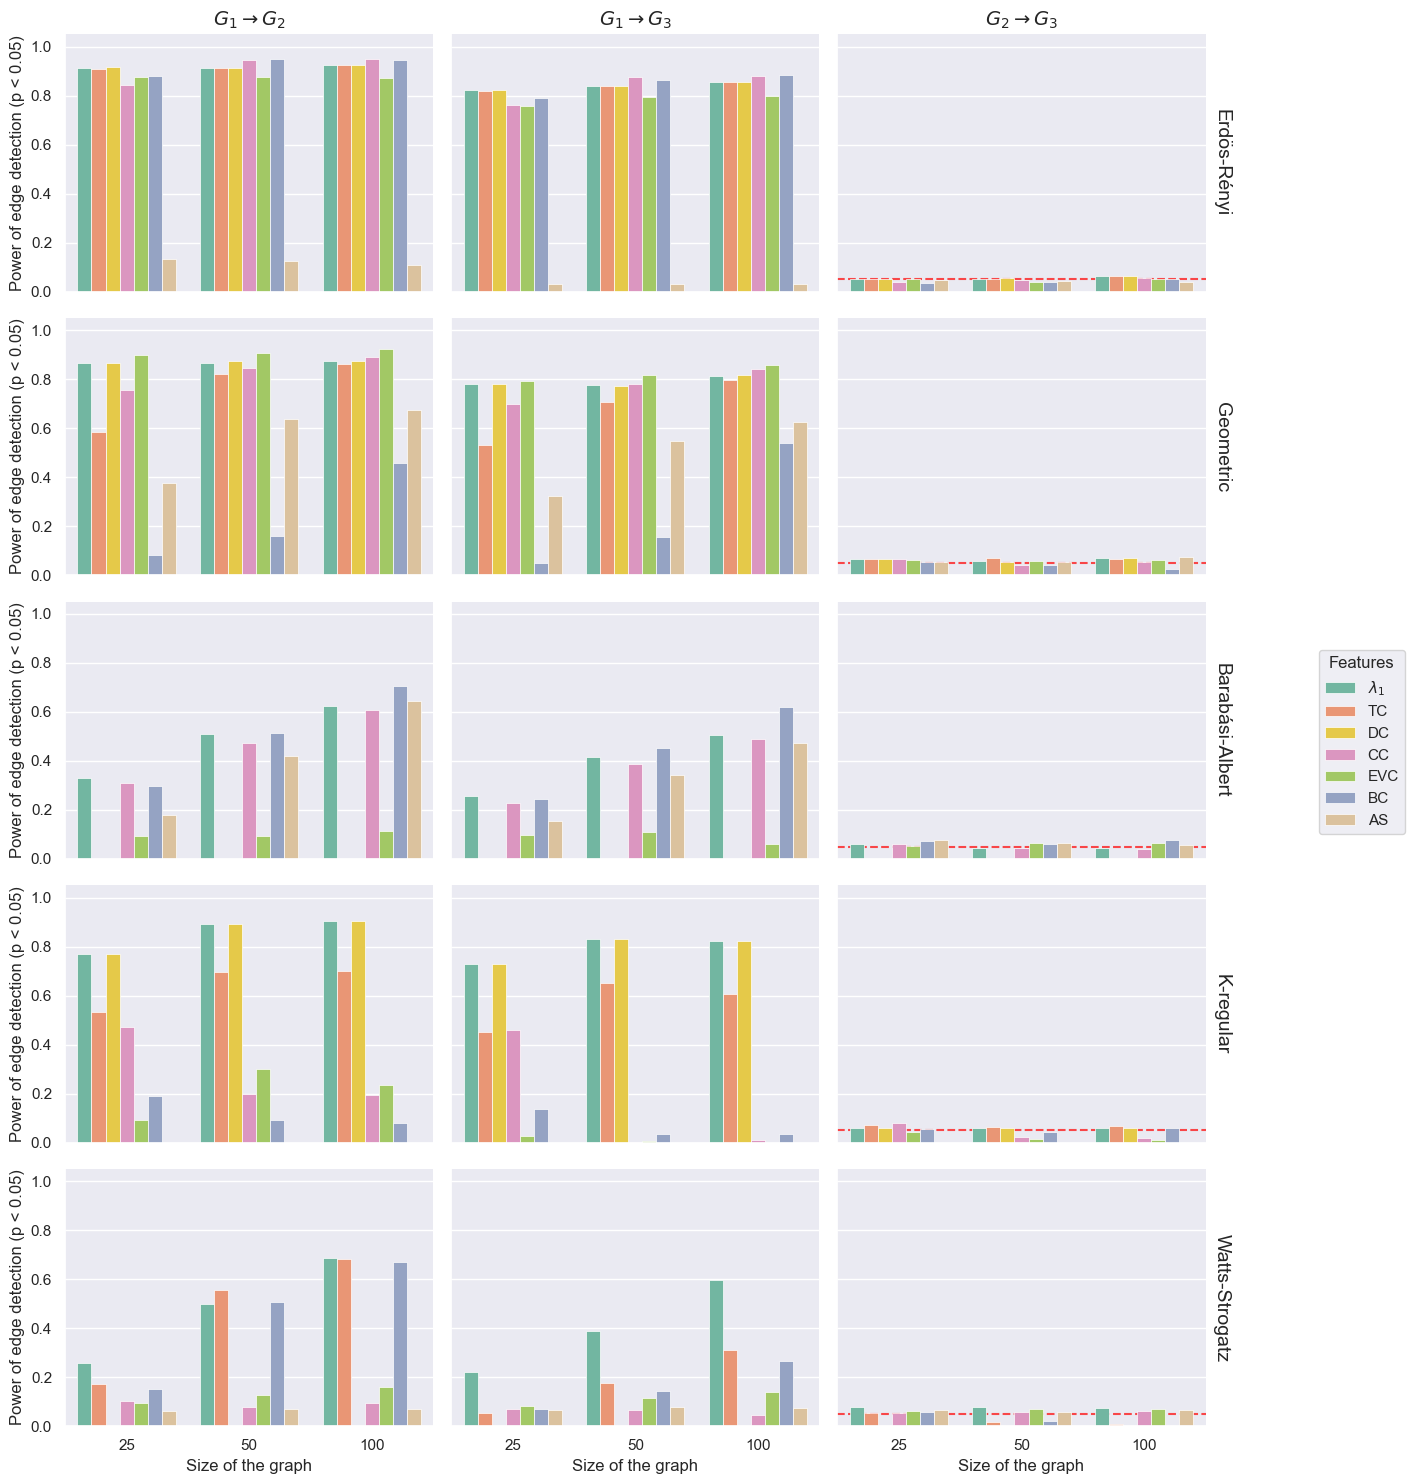

Arquivo salvo como: plot_poder_features_uniform_Caso_3_Matriz.pdf


In [15]:

# Definições base do seu escopo (ajuste se necessário)
ruido = "uniform"
R = 50
caso = "Caso_3"
features = [r"$\lambda_1$", "TC", "BC", "CC", "EVC", "DC", "AS"]

# 1. Carregando os dados salvos do Caso 3
path_dir = os.path.join("..", "dados", "dados_plots", "simulacao_1", caso)
path_resultados = os.path.join(path_dir, f"resultados_{caso}_{ruido}_R{R}.csv")
df_resultados = pd.read_csv(path_resultados)

# 2. Traduzindo as direções para o formato Matemático (LaTeX)
mapa_arestas = {
    "A->B": r"$G_1 \to G_2$",
    "A->C": r"$G_1 \to G_3$",
    "B->C": r"$G_2 \to G_3$"
}
# Cria a coluna que vai gerar exatamente as 3 colunas no gráfico
df_resultados['Aresta_Formatada'] = df_resultados['Aresta_Avaliada'].map(mapa_arestas)

# 3. Aplicando o tema e calculando a ordem/cores globais
sns.set_theme(style="darkgrid")

# Ordena da feature com maior taxa de rejeição geral para a menor
ordem_features = df_resultados.groupby("Feature")["Taxa_Rejeicao"].mean().sort_values(ascending=False).index.tolist()

# Fixa as cores para manter a consistência visual em relação aos outros gráficos
paleta_bruta = sns.color_palette("Set2", n_colors=len(features))
dict_cores = dict(zip(features, paleta_bruta))

# 4. Gerando os gráficos facetados em Matriz (5 Linhas x 3 Colunas)
g = sns.catplot(
    data=df_resultados,
    x="Vértices",             
    y="Taxa_Rejeicao",                
    hue="Feature",
    hue_order=ordem_features, 
    col="Aresta_Formatada",   # <--- AQUI: Gera as 3 colunas!
    row="Titulo_Subplot",     
    kind="bar",
    height=3.0,               # Altura um pouco menor para caber bem na página A4
    aspect=1.3,               # Ajuste da proporção para não espremer as 3 colunas
    palette=dict_cores,       
    edgecolor="white",        
    linewidth=0.5,
    margin_titles=True        
)

# 5. Ajustando títulos e eixos
g.set_axis_labels("Size of the graph", "Power of edge detection (p < 0.05)")
g.set_titles(col_template="{col_name}", row_template="{row_name}", size=14)

# 6. Adiciona uma linha horizontal pontilhada vermelha no y=0.05 apenas para B->C (Erro Tipo I)
# Para fazer isso elegantemente, iteramos sobre os eixos
for (row_val, col_val), ax in g.axes_dict.items():
    if col_val == r"$G_2 \to G_3$":
        ax.axhline(0.05, color='red', linestyle='--', linewidth=1.5, alpha=0.7, zorder=0)

# 7. Movendo a Legenda para fora da área dos subplots
sns.move_legend(g, "center left", bbox_to_anchor=(1.05, 0.5), title="Features", frameon=True)

# 8. Forçando os limites do eixo Y
for ax in g.axes.flatten():
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# 9. Salvamento
nome_arquivo = f"plot_poder_features_{ruido}_{caso}_Matriz.pdf"
path_figuras = os.path.join("..", "resultados", "figuras", caso, ruido)
os.makedirs(path_figuras, exist_ok=True)
g.savefig(os.path.join(path_figuras, nome_arquivo), format='pdf', bbox_inches='tight')
print(f"Arquivo salvo como: {nome_arquivo}")

#### 3) Plot comparação entre estimativa média e valor real

In [6]:
logging.getLogger().setLevel(logging.ERROR) 

R = 50               
N_SIMS = 1000           
alpha = 0.05          
ruido = "uniform"
estrutura = {"A->B"}

vertices_list = [25, 50, 100] 
modelos = ["erdos_renyi", "geometric", "barabasi_albert", "k_regular", "watts_strogatz"]
features = [r"$\lambda_1$", "TC", "BC", "CC", "EVC", "DC", "AS"]

resultados = []

print("Iniciando simulações de Monte Carlo para cálculo de Coeficientes...")

for modelo in modelos:
    for n_v in vertices_list:
        print(f"➜ Processando: Modelo = {modelo.upper():<16} | Vértices = {n_v}")
        
        # Dicionários para guardar os dados de cada simulação
        estimativas_lista = {feat: [] for feat in features}
        
        for sim in range(N_SIMS):
            A, B = gerar_estrutura_causal_logits(R, ruido, estrutura)
            df_A, df_B = gerar_amostras_grafos(modelo, n_v, A, B, R)
            
            for feature in features:
                nome_feature = "Lambda" if feature == r"$\lambda_1$" else feature
                col_A = f"{nome_feature}_A"
                col_B = f"{nome_feature}_B"
                
                df_merged = pd.concat([df_A[feature].rename(col_A), 
                                       df_B[feature].rename(col_B)], axis=1)
                                
                # Padronização (Z-Score)
                stds = df_merged.std().replace(0, 1e-9)
                df_merged = (df_merged - df_merged.mean()) / stds
                
                model_desc = f"{col_B} ~ {col_A}"
                
                try:
                    model_sem = semopy.Model(model_desc)
                    model_sem.fit(df_merged)
                    ins = model_sem.inspect()
                    
                    row = ins[(ins['lval'] == col_B) & (ins['rval'] == col_A)]
                    if not row.empty:
                        # Extrai a Estimativa (Coeficiente) da regressão
                        estimate = row['Estimate'].values[0]
                        if not pd.isna(estimate):
                            estimativas_lista[feature].append(float(estimate))
                except Exception as e:
                    print(e)
                
        # Calcula a média das estimativas para este modelo e n_vertices
        for feature in features:
            if len(estimativas_lista[feature]) > 0:
                media_estimativa = np.mean(estimativas_lista[feature])
            else:
                media_estimativa = 0.0 # Caso a feature seja constante em todas as simulações
                
            resultados.append({
                "Modelo": modelo,
                "Vértices": n_v,
                "Feature": feature,
                "Estimativa_Media": media_estimativa
            })

# =========================================================
# 3. VISUALIZAÇÃO DOS COEFICIENTES ESTIMADOS (Estilo Artigo)
# =========================================================
df_resultados = pd.DataFrame(resultados)



titulos_formatados = {
    "erdos_renyi": "Erdös-Rényi",
    "geometric": "Geometric",
    "barabasi_albert": "Barabási-Albert",
    "k_regular": "K-Regular",
    "watts_strogatz": "Watts-Strogatz"
}


mapa_titulos = {mod: f"{titulos_formatados.get(mod, mod)}." for i, mod in enumerate(modelos)}
df_resultados['Titulo_Subplot'] = df_resultados['Modelo'].map(mapa_titulos)
path_resultados = os.path.join(r"..\dados\dados_plots\simulacao_1", f"estimativas_features_{ruido}R{R}.csv")
df_resultados.to_csv(path_resultados)

Iniciando simulações de Monte Carlo para cálculo de Coeficientes...
➜ Processando: Modelo = ERDOS_RENYI      | Vértices = 25
➜ Processando: Modelo = ERDOS_RENYI      | Vértices = 50
➜ Processando: Modelo = ERDOS_RENYI      | Vértices = 100
➜ Processando: Modelo = GEOMETRIC        | Vértices = 25
➜ Processando: Modelo = GEOMETRIC        | Vértices = 50
➜ Processando: Modelo = GEOMETRIC        | Vértices = 100
➜ Processando: Modelo = BARABASI_ALBERT  | Vértices = 25
➜ Processando: Modelo = BARABASI_ALBERT  | Vértices = 50
➜ Processando: Modelo = BARABASI_ALBERT  | Vértices = 100
➜ Processando: Modelo = K_REGULAR        | Vértices = 25
➜ Processando: Modelo = K_REGULAR        | Vértices = 50
➜ Processando: Modelo = K_REGULAR        | Vértices = 100
➜ Processando: Modelo = WATTS_STROGATZ   | Vértices = 25
➜ Processando: Modelo = WATTS_STROGATZ   | Vértices = 50
➜ Processando: Modelo = WATTS_STROGATZ   | Vértices = 100


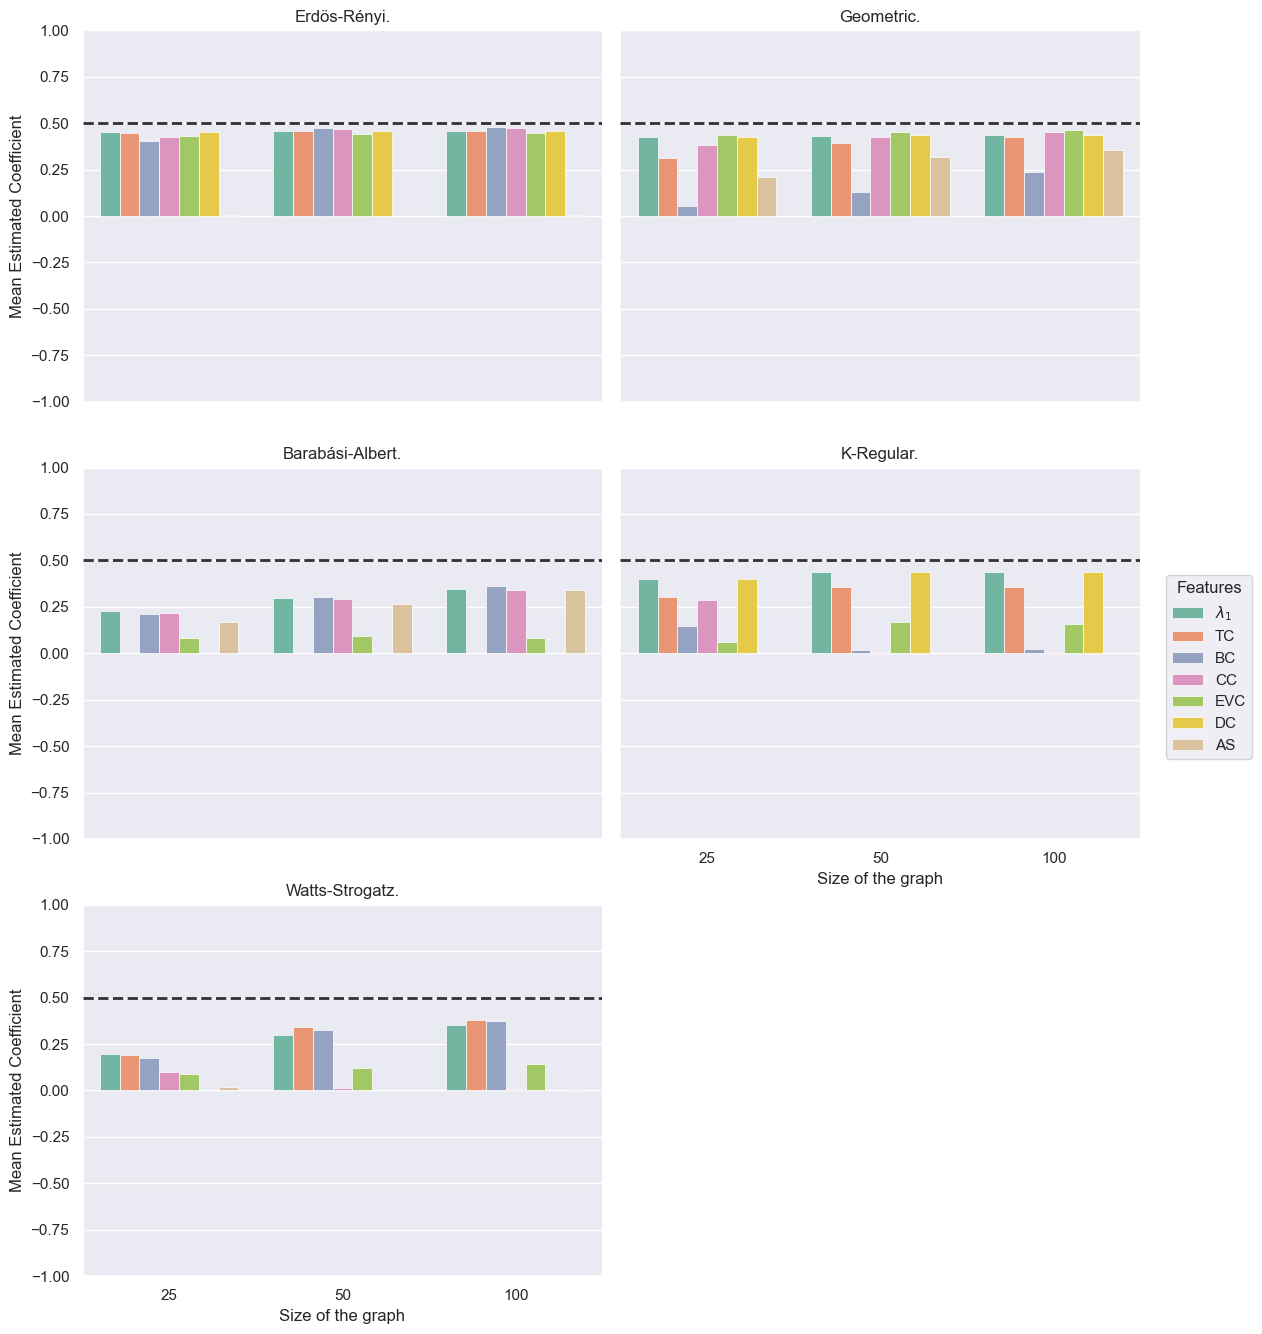

Arquivo salvo como: plot_media_estimativa_features_uniform.pdf


In [10]:
path_resultados = os.path.join(r"..\dados\dados_plots\simulacao_1", f"estimativas_features_{ruido}R{R}.csv")
df_resultados = pd.read_csv(path_resultados)

# Configurando estilo
sns.set_theme(style="darkgrid")

paleta_cores = sns.color_palette("Set2", n_colors=len(features))

# Criando o gráfico
g = sns.catplot(
    data=df_resultados,
    x="Vértices",             
    y="Estimativa_Media", # Plotando a média dos coeficientes
    hue="Feature",            
    col="Titulo_Subplot",     
    kind="bar",
    height=4.5, 
    aspect=1.2, 
    col_wrap=2,               
    palette=paleta_cores,     
    edgecolor="white",        
    linewidth=0.5
)

# Ajustes de eixos e títulos
g.set_axis_labels("Size of the graph", "Mean Estimated Coefficient")
g.set_titles("{col_name}", size=12)

# Desenhando a linha do Coeficiente Real (0.5) em todos os subplots
valor_real_coeficiente = 0.5 

for ax in g.axes.flatten():
    ax.axhline(valor_real_coeficiente, ls='--', linewidth=2, color='black', alpha=0.8, zorder=5)
    # Ajuste manual do eixo Y para garantir que a linha de 0.5 fique bem visível, mesmo se houver coeficientes negativos
    ax.set_ylim(-1.0, 1.0) 

sns.move_legend(g, "center left", bbox_to_anchor=(1.0, 0.5), title="Features", frameon=True)

plt.tight_layout()
plt.show()

nome_arquivo = f"plot_media_estimativa_features_{ruido}.pdf"
path = os.path.join("..", "resultados", "figuras", "Caso_2", ruido)
os.makedirs(path, exist_ok=True)
g.savefig(os.path.join(path, nome_arquivo), format='pdf', bbox_inches='tight')
print(f"Arquivo salvo como: {nome_arquivo}")